In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df["Residence_type"].unique()

array(['Urban', 'Rural'], dtype=object)

In [4]:
df["work_type"].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [5]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [6]:
df.shape

(5110, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [8]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [9]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.fillna(df["bmi"].mean())
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [12]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [13]:
df["stroke"].unique()

array([1, 0])

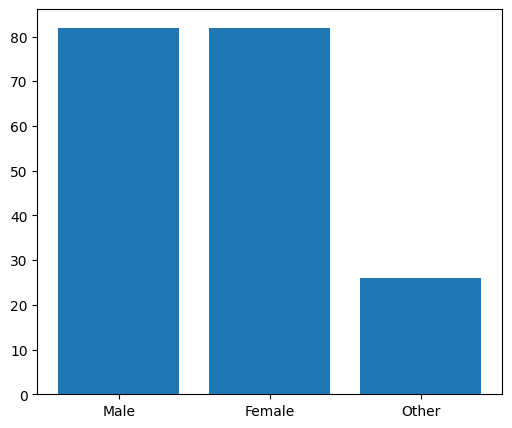

In [14]:
plt.figure(figsize=(6,5))
plt.bar(df["gender"],df["age"])
plt.show()

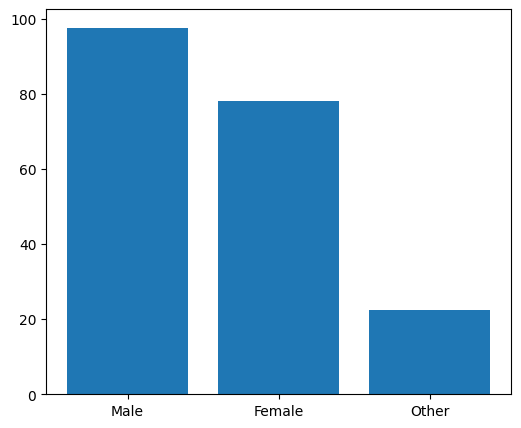

In [15]:
plt.figure(figsize=(6,5))
plt.bar(df["gender"],df["bmi"])
plt.show()

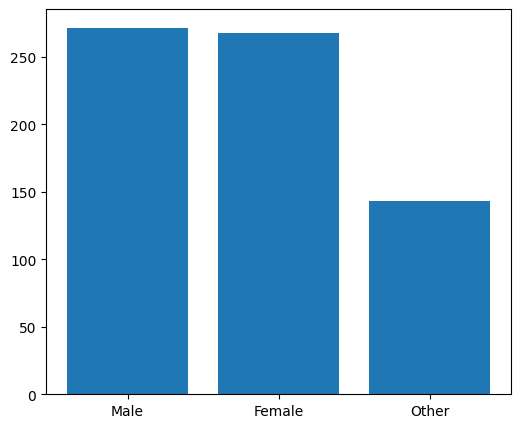

In [16]:
plt.figure(figsize=(6,5))
plt.bar(df["gender"],df["avg_glucose_level"])
plt.show()

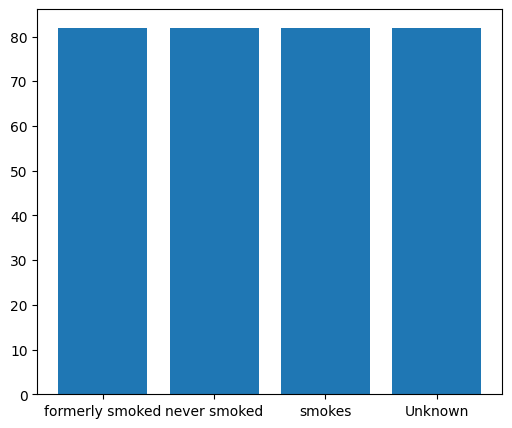

In [17]:
plt.figure(figsize=(6,5))
plt.bar(df["smoking_status"],df["age"])
plt.show()

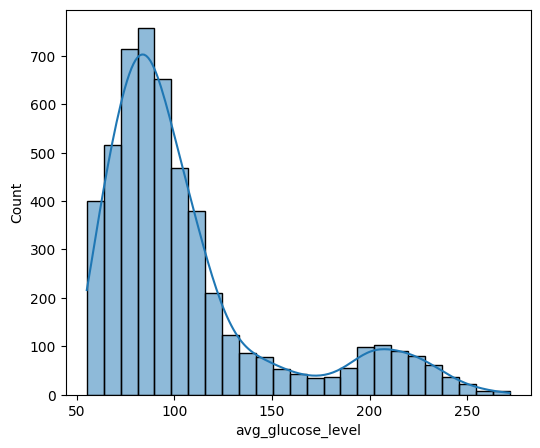

In [18]:
plt.figure(figsize=(6,5))
sns.histplot(df,x="avg_glucose_level",bins=25,kde=True)
plt.show()

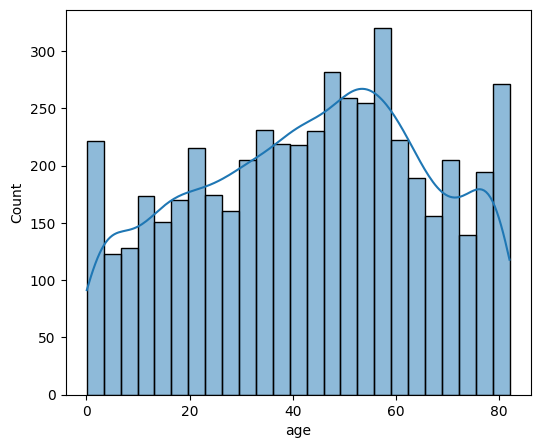

In [19]:
plt.figure(figsize=(6,5))
sns.histplot(df,x="age",bins=25,kde=True)
plt.show()

In [20]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [21]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [22]:
Label_encoder = LabelEncoder()

col = ['gender','ever_married','work_type', 'Residence_type','smoking_status']

for i in col:
    df[i] = Label_encoder.fit_transform(df[i])
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,2,1,228.69,36.600000,1,1
1,51676,0,61.0,0,0,1,3,0,202.21,28.893237,2,1
2,31112,1,80.0,0,1,1,2,0,105.92,32.500000,2,1
3,60182,0,49.0,0,0,1,2,1,171.23,34.400000,3,1
4,1665,0,79.0,1,0,1,3,0,174.12,24.000000,2,1


In [23]:
scaler = StandardScaler()

col = ['age','avg_glucose_level', 'bmi']

df[col] = scaler.fit_transform(df[col])
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,1.051434,0,1,1,2,1,2.706375,1.001234e+00,1,1
1,51676,0,0.786070,0,0,1,3,0,2.121559,4.615554e-16,2,1
2,31112,1,1.626390,0,1,1,2,0,-0.005028,4.685773e-01,2,1
3,60182,0,0.255342,0,0,1,2,1,1.437358,7.154182e-01,3,1
4,1665,0,1.582163,1,0,1,3,0,1.501184,-6.357112e-01,2,1


In [24]:
X = df.drop(["id","stroke"],axis=1)
y = df[["stroke"]]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [25]:
models = {
    "LR":LogisticRegression(),
    "KNN":KNeighborsClassifier(),
    "SVC":SVC(),
    # "MNB":MultinomialNB(),
    "XGB":XGBClassifier(),
    "ADB":AdaBoostClassifier(),
    "GB":GradientBoostingClassifier()
}

In [26]:
result = []
for name , model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    result.append([name,accuracy_score(y_pred,y_test)])
    # print(name,accuracy_score(y_pred,y_test))

df_result = pd.DataFrame(result,columns=["name","accuracy_score"])

C:\Users\Amir sohail\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Amir sohail\AppData\Roaming\Python\Python314\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Amir sohail\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Amir sohail\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A c

In [27]:
df_result

,name,accuracy_score
0,LR,0.939335
1,KNN,0.936399
2,SVC,0.939335
3,XGB,0.937378
4,ADB,0.939335
5,GB,0.939335


In [28]:
model = GradientBoostingClassifier()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
accuracy_score(y_pred,y_test)

C:\Users\Amir sohail\AppData\Roaming\Python\Python314\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.9393346379647749

In [30]:
from joblib import dump

dump(model,"Final Model.pkl")
dump(scaler,"scaler.pkl")
dump(X.columns.tolist(),"columns.pkl")

['columns.pkl']